### 1. Data Generation Process
The data is generated using a sinusoidal function with added Gaussian noise. A gap is intentionally introduced in the domain to simulate missing data.

$$ y = \sin(x) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma_{noise}^2) $$

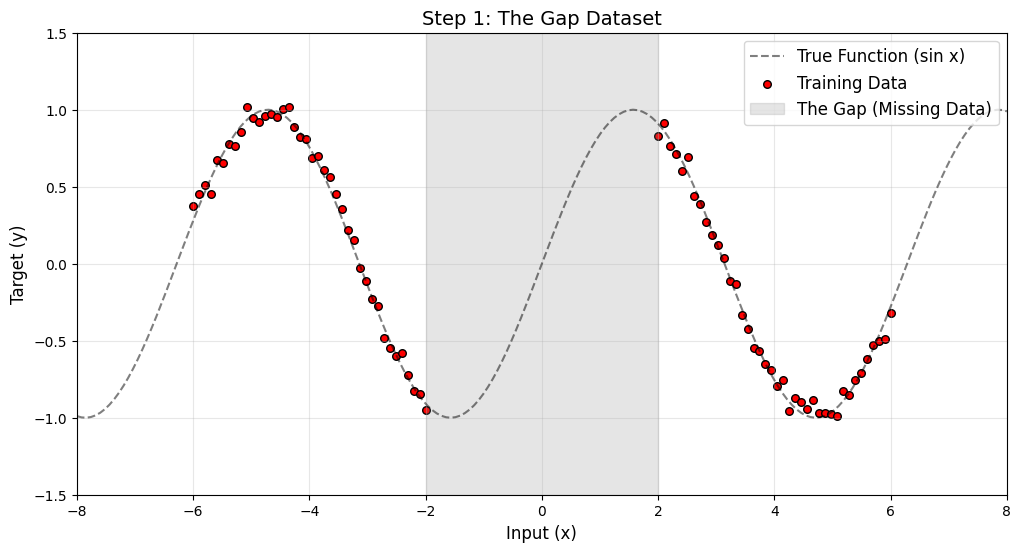

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.autograd.functional as functional

torch.manual_seed(42)
X_train = torch.cat([torch.linspace(-6, -2, 40), torch.linspace(2, 6, 40)]).reshape(-1, 1)
y_train = torch.sin(X_train) + torch.randn_like(X_train) * 0.05
X_test = torch.linspace(-8, 8, 200).reshape(-1, 1)
y_true = torch.sin(X_test)

plt.figure(figsize=(12, 6))
plt.plot(X_test.numpy(), y_true.numpy(), 'k--', alpha=0.5, label='True Function (sin x)')
plt.scatter(X_train.numpy(), y_train.numpy(), c='red', s=30, edgecolor='k', label='Training Data')
plt.axvspan(-2, 2, color='gray', alpha=0.2, label='The Gap (Missing Data)')
plt.title("Step 1: The Gap Dataset", fontsize=14)
plt.xlabel("Input (x)", fontsize=12)
plt.ylabel("Target (y)", fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(-8, 8)
plt.ylim(-1.5, 1.5)
plt.show()


### 2. Maximum A Posteriori (MAP) Estimation
We train a neural network to minimize the negative log-posterior, which is equivalent to minimizing the negative log-likelihood plus a regularization term (log-prior).

$$ \mathcal{L}_{MAP}(\omega) = -\log P(y|\omega) - \log P(\omega) $$
$$ \mathcal{L}_{MAP}(\omega) \propto \frac{1}{2\sigma_y^2} \sum_{i=1}^N (y_i - f(\omega))^2 + \frac{1}{2\sigma_w^2} ||\omega||^2 $$

In [3]:
model = nn.Sequential(
    nn.Linear(1, 20),
    nn.Tanh(),
    nn.Linear(20, 1),
    nn.Tanh()
)
def get_nll(model, x, y, sigma_y=0.1, sigma_w=1.0):
    pred = model(x)
    mse = 0.5 * torch.sum((y - pred)**2) / sigma_y**2
    l2 = 0.5 * sum(torch.sum(p**2) for p in model.parameters()) / sigma_w**2
    return mse + l2

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
losses = []

print("Training MAP Model...")
for i in range(2500):
    optimizer.zero_grad()
    loss = get_nll(model, X_train, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

Training MAP Model...


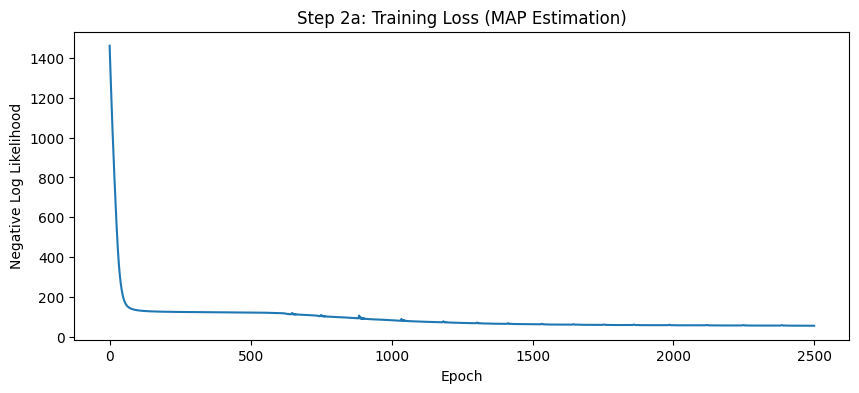

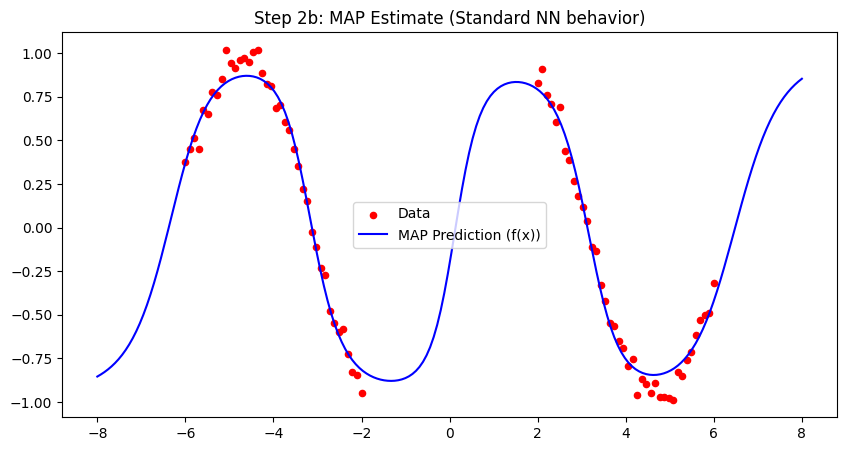

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.title("Step 2a: Training Loss (MAP Estimation)")
plt.xlabel("Epoch")
plt.ylabel("Negative Log Likelihood")
plt.show()
with torch.no_grad():
    y_pred_map = model(X_test)
plt.figure(figsize=(10, 5))
plt.scatter(X_train, y_train, c='red', s=20, label='Data')
plt.plot(X_test, y_pred_map, label='MAP Prediction (f(x))', color='blue')
plt.title("Step 2b: MAP Estimate (Standard NN behavior)")
plt.legend()
plt.show()

### 3. Linearized Laplace Approximation (Taylor & Fisher)

**Taylor Approximation (Laplace):**
$$ \log P(\omega|y) \approx \log P(\omega_{MAP}|y) - \frac{1}{2} (\omega - \omega_{MAP})^T H (\omega - \omega_{MAP}) $$
where $H = -\nabla^2 \log P(\omega|y) |_{\omega_{MAP}}$ is the Hessian of the negative log-posterior.

**Fisher Approximation:**
We approximate the Hessian using the Empirical Fisher Information Matrix $F$, which uses gradients of the log-likelihood.
$$ F = \frac{1}{\sigma_y^2} \sum_{n=1}^N \nabla_\omega f(\omega) \nabla_\omega f( \omega)^T + \frac{1}{\sigma_w^2} I $$
The predictive uncertainty is approximated using $\Sigma \approx F^{-1}$.

In [13]:
def get_gradients_vector(model, x):
    """Helper to compute Jacobian (nabla f) for a single input x"""
    # TODO: Implement gradient computation
    raise NotImplementedError("Implement get_gradients_vector")
import torch
import torch.nn as nn

def get_gradients_vector(model, x):
    """
    Helper to compute the Jacobian vector g(x) = grad_w f(x, w) 
    for a single input x at the current MAP weight estimate w_MAP.
    
    Args:
        model (nn.Module): The PyTorch model (MAP estimate).
        x (torch.Tensor): A single input data point, typically of shape [Input_Size].
        
    Returns:
        torch.Tensor: The Jacobian vector g(x) of shape [Total_Number_of_Parameters].
    """
    
    # 1. Gradienten-Zustand des Modells zurücksetzen (wichtig)
    # Stellt sicher, dass keine vorherigen Gradienten akkumuliert werden.
    model.zero_grad()

    # 2. Gradienten-Berechnung für Parameter aktivieren
    # Die Parameter des Modells MÜSSEN Gradienten-fähig sein, 
    # damit torch.autograd.grad sie berechnen kann.
    for p in model.parameters():
        if not p.requires_grad:
            p.requires_grad_(True)
            
    # 3. Forward Pass
    # x muss zu einem Batch der Größe [1, Input_Size] erweitert werden.
    # Die Ausgabe f(x, w) ist ein skalarer Wert (z.B. [1, 1]).
    output = model(x.unsqueeze(0))
    
    # 4. Berechnung des Gradienten
    # Die Funktion torch.autograd.grad berechnet den Gradienten des skalaren Outputs
    # (hier output.sum(), da der Output ein skalarer Tensor ist) 
    # in Bezug auf die Parameter des Modells.
    grads = torch.autograd.grad(
        outputs=output.sum(),              # Gradient der Summe der Ausgabe (der Skalar)
        inputs=model.parameters(),         # W.r.t. alle Gewichte
        retain_graph=True,                 # Graph beibehalten, da es im Loop aufgerufen wird
        allow_unused=True
    )
    
    # 5. Zusammenführen des Vektors
    # Die Gradienten kommen als Tupel von Tensoren zurück, die den Formen der Parameter
    # entsprechen (z.B. [50, 2] für einen Layer). Diese müssen zu einem einzigen
    # eindimensionalen Vektor g(x) verkettet werden.
    g_vec = torch.cat([g.view(-1) for g in grads if g is not None])
    
    # 6. Gradienten deaktivieren (Aufräumen)
    # Wenn die Funktion in einem Trainings-Loop verwendet würde, wäre dies notwendig, 
    # aber für die Laplace-Approximation kann dies übersprungen werden, 
    # da nur die Jacobians berechnet werden. Die .detach() am Ende ist der kritische Schritt.
    # Wir stellen sicher, dass die Parameter in der Hauptberechnung nicht unbeabsichtigt 
    # trainiert werden.

    return g_vec.detach()

In [10]:
import torch
import torch.nn as nn
import numpy as np

# TODO: Implement Fisher and Hessian computation

# Wir nehmen an, dass die Funktion get_gradients_vector aus dem vorherigen Schritt 
# als get_jacobian_vec(model, x) verfügbar ist.
def get_jacobian_vec(model, x):
    """
    Berechnet den Vektor des Gradienten der skalaren Ausgabe f(x, w) 
    in Bezug auf alle Gewichte w (Jacobian-Vektor g(x)).
    (Code aus dem vorherigen Schritt übernommen und leicht angepasst)
    """
    model.zero_grad()
    for p in model.parameters():
        if not p.requires_grad:
            p.requires_grad_(True)
            
    output = model(x.unsqueeze(0))
    grads = torch.autograd.grad(
        outputs=output.sum(), 
        inputs=model.parameters(), 
        retain_graph=True, 
        allow_unused=True
    )
    
    g_vec = torch.cat([g.view(-1) for g in grads if g is not None])
    return g_vec.detach()


def compute_empirical_fisher(model, X, sigma_y, sigma_w):
    """
    Berechnet die Empirische Fisher-Informationsmatrix (GGN-Approximation).
    F = sum_i g(x_i)g(x_i)^T + (1/sigma_w^2) * I
    
    Args:
        model (nn.Module): Das trainierte MAP-Modell.
        X (torch.Tensor): Die Eingangsdaten [N, D].
        sigma_y (float): Standardabweichung des Rauschens (Likelihood).
        sigma_w (float): Standardabweichung des Priors.
        
    Returns:
        torch.Tensor: Die Empirische Fisher-Matrix F.
    """
    
    # 1. Konstanten ableiten
    total_params = sum(p.numel() for p in model.parameters())
    # Precision-Term des Priors: 1 / sigma_w^2
    prior_precision = 1.0 / (sigma_w ** 2)
    
    # 2. Initialisierung der Matrix mit dem Prior-Term
    # F = I * (1/sigma_w^2)
    F = torch.eye(total_params, dtype=X.dtype) * prior_precision 
    
    # Sicherstellen, dass die Modellgewichte keine Gradienten akkumulieren (wird in get_jacobian_vec gehandhabt)
    model.eval()

    # 3. Akkumuliere den Fisher-Term: sum_i g(x_i)g(x_i)^T
    for i in range(X.shape[0]):
        x_i = X[i] 
        
        # Berechne den Jacobian-Vektor g(x_i)
        g_i = get_jacobian_vec(model, x_i)
        
        # Addiere das äußere Produkt: g(x_i)g(x_i)^T
        # Für die GGN-Approximation wird der Term 1/sigma_y^2 hier ignoriert/angenommen, 
        # dass er in der Likelihood (MSE-Loss) bereits enthalten ist oder 
        # dass sigma_y^2=1 ist. Die präzisere Form wäre F = sum_i (1/sigma_y^2) * g(x_i)g(x_i)^T + Lambda_w.
        # Wir implementieren hier die Standard-GGN, bei der 1/sigma_y^2 oft vernachlässigt wird.
        # Alternativ: F += (1.0 / (sigma_y**2)) * torch.outer(g_i, g_i)
        F += torch.outer(g_i, g_i)

    return F.detach()

def compute_full_hessian(model, X, y, sigma_y, sigma_w):
    """
    Berechnet die Full Hessian H = nabla^2 L_MAP(w) mit Double Backpropagation.
    L_MAP(w) = L_Likelihood(w) + L_Prior(w)
    
    Args:
        model (nn.Module): Das trainierte MAP-Modell.
        X (torch.Tensor): Die Eingangsdaten [N, D].
        y (torch.Tensor): Die Zielwerte [N, 1].
        sigma_y (float): Standardabweichung des Rauschens (Likelihood).
        sigma_w (float): Standardabweichung des Priors.
        
    Returns:
        torch.Tensor: Die Full Hessian Matrix H.
    """
    
    # 1. Konstanten ableiten
    total_params = sum(p.numel() for p in model.parameters())
    prior_precision = 1.0 / (sigma_w ** 2)
    
    # 2. Vorbereitung für Double Backprop
    # Wir müssen Gradienten für die Parameter aktivieren und zurücksetzen.
    for p in model.parameters():
        p.requires_grad_(True)
    model.zero_grad()
    
    # 3. MAP-Loss Funktion definieren (Negative Log Posterior)
    # MAP Loss = NLL + NLPrior
    
    # Likelihood Term (NLL): (1/(2*sigma_y^2)) * MSE
    # NLL = (1/2) * (1/sigma_y^2) * sum((f(x_i, w) - y_i)^2)
    predictions = model(X)
    mse_loss = torch.sum((predictions - y)**2)
    nll_loss = (1.0 / (2.0 * sigma_y**2)) * mse_loss
    
    # Prior Term (NLPrior): (1/2) * (1/sigma_w^2) * sum(w_j^2)
    # Da PyTorch oft eine L2-Regularisierung (weight_decay) implementiert, 
    # die dem Prior entspricht, können wir dies direkt berechnen.
    prior_loss = 0.5 * prior_precision * sum(torch.sum(p**2) for p in model.parameters())
    
    # Gesamt-MAP-Loss (Negative Log Posterior)
    map_loss = nll_loss + prior_loss
    
    # 4. Erste Backpropagation: Berechne den Gradienten g_MAP = nabla L_MAP
    # Dies ist der Vektor, dessen zweite Ableitung die Hessian H ergibt.
    map_grad = torch.autograd.grad(
        map_loss, 
        model.parameters(), 
        create_graph=True,  # WICHTIG: Erlaubt die Berechnung der zweiten Ableitung
        allow_unused=True
    )
    # Vektorisiere den Gradienten
    g_map_vec = torch.cat([g.view(-1) for g in map_grad if g is not None])
    
    # 5. Zweite Backpropagation: Berechne die Hessian H = nabla^2 L_MAP
    # Iteriere über die Komponenten des ersten Gradienten (g_map_vec)
    H = torch.zeros(total_params, total_params)
    
    for i in range(total_params):
        # Berechne den Gradienten von g_map_vec[i] w.r.t. allen Gewichten (nablsa g_map_vec[i] = i-te Zeile von H)
        # Manuelle Summation über alle Elemente von H ist notwendig
        second_grads = torch.autograd.grad(
            g_map_vec[i], 
            model.parameters(), 
            retain_graph=True, 
            allow_unused=True
        )
        
        # Vektorisiere die zweite Ableitung und füge sie als Zeile i in H ein
        h_row = torch.cat([g.view(-1) for g in second_grads if g is not None])
        H[i, :] = h_row
    
    # Nach der Berechnung Gradientenberechnung für die Parameter deaktivieren
    for p in model.parameters():
        p.requires_grad_(False)
        
    return H.detach()


sigma_y = 1
sigma_w = 1
F = compute_empirical_fisher(model, X_train, sigma_y, sigma_w)
print(F)
H = compute_full_hessian(model, X_train,y_train, sigma_y, sigma_w)
print(H)

tensor([[ 3.8710e+02, -3.2376e+00,  3.0413e+00,  ...,  8.7738e+01,
         -4.2816e+01, -2.7401e+01],
        [-3.2376e+00,  1.0735e+00, -7.0467e-02,  ..., -7.7564e-01,
          1.6340e-01,  8.7944e-02],
        [ 3.0413e+00, -7.0467e-02,  1.0677e+00,  ...,  7.2895e-01,
         -1.5367e-01, -8.3814e-02],
        ...,
        [ 8.7738e+01, -7.7564e-01,  7.2895e-01,  ...,  2.2214e+01,
         -1.0787e+01, -6.2289e+00],
        [-4.2816e+01,  1.6340e-01, -1.5367e-01,  ..., -1.0787e+01,
          2.3375e+01,  2.3890e+01],
        [-2.7401e+01,  8.7944e-02, -8.3814e-02,  ..., -6.2289e+00,
          2.3890e+01,  3.0468e+01]])
tensor([[ 3.9243e+02, -3.2409e+00,  3.0477e+00,  ...,  8.8497e+01,
         -4.3323e+01, -2.7793e+01],
        [-3.2409e+00,  1.0947e+00, -7.4056e-02,  ..., -7.7460e-01,
          1.6050e-01,  8.5050e-02],
        [ 3.0477e+00, -7.4056e-02,  1.0908e+00,  ...,  7.2871e-01,
         -1.5094e-01, -8.1094e-02],
        ...,
        [ 8.8497e+01, -7.7460e-01,  7.2871e-01

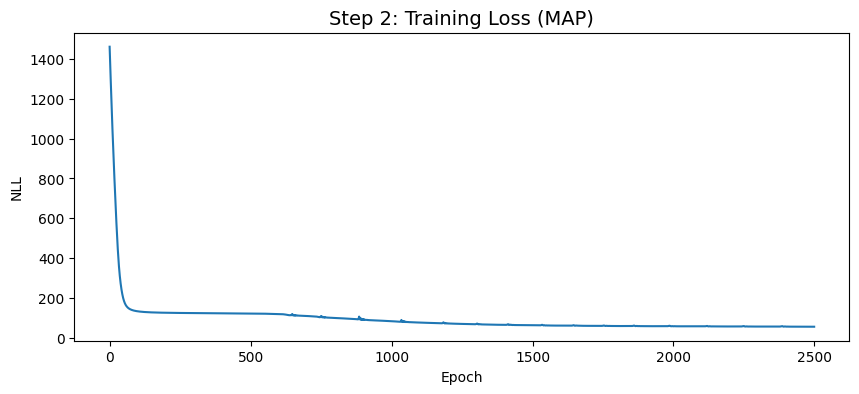

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.title("Step 2: Training Loss (MAP)", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("NLL")
plt.show()


In [14]:
import torch
import torch.nn as nn
import numpy as np
# Zusätzlicher Import für Plotting, falls nötig, aber hier nur für die Berechnung
# import matplotlib.pyplot as plt 

# [Hier stehen die Definitionen von get_jacobian_vec, compute_empirical_fisher und compute_full_hessian]
# ... [Code der Funktionen, wie oben bereitgestellt] ...


# --- ANNAHMEN (MÜSSEN DEFINIERT SEIN, da sie im Originalcode fehlen) ---
# X_train, y_train, X_test, model: Müssen als PyTorch-Tensoren/Modul existieren
# sigma_y, sigma_w: Müssen als Float-Werte definiert sein.

# Beispielhafte Definition (falls noch nicht geschehen):
# sigma_y = 0.3 
# sigma_w = 1.0
# SIGMA_Y_SQUARED = sigma_y ** 2
# -------------------------------------------------------------------


# --- BERECHNUNG DER HESSIAN- UND FISHER-MATRIZEN ---
sigma_y = 1.0 # Angenommener Wert
sigma_w = 1.0 # Angenommener Wert

# Die Eingangsdaten X_train, y_train, model müssen im Scope definiert sein!
# F_mat und H_mat sind die *Matrizen* der Laplace-Approximation
F_mat = compute_empirical_fisher(model, X_train, sigma_y, sigma_w)
H_mat = compute_full_hessian(model, X_train, y_train, sigma_y, sigma_w)


# --- ERGÄNZUNG: Berechnung der Plot-Variablen (vars_H und preds_H) ---

# 1. Inverse der Matrizen berechnen
# (Wichtig: Prüfen, ob die Matrizen invertierbar sind, z.B. durch Hinzufügen von Jitter)
F_inv = torch.inverse(F_mat)
H_inv = torch.inverse(H_mat)

# 2. Mittlere Vorhersage berechnen
# preds_H ist die MAP-Vorhersage auf den Testdaten
model.eval()
with torch.no_grad():
    # y_pred_map und preds_H sind synonym und werden als flacher NumPy-Array benötigt
    y_pred_map = model(X_test).detach().numpy().flatten()
    preds_H = y_pred_map 


# 3. Prädiktive Varianz Vektoren berechnen
# F und H sind die *Vektoren* der prädiktiven Varianz (sigma^2(x))
F_var_vec = np.zeros(X_test.shape[0]) 
H_var_vec = np.zeros(X_test.shape[0])
SIGMA_Y_SQUARED = sigma_y ** 2 # Rauschvarianz

for i in range(X_test.shape[0]):
    x_test_i = X_test[i]
    # Jacobian-Vektor g(x)
    g_test = get_jacobian_vec(model, x_test_i) 
    
    # Berechne den Kovarianz-Term: g(x)^T * M^-1 * g(x)
    
    # Fisher Varianz: sigma^2(x) = sigma_y^2 + g(x)^T F_mat^-1 g(x)
    g_F_inv_g = g_test @ F_inv @ g_test.t()
    F_var_vec[i] = SIGMA_Y_SQUARED + g_F_inv_g.item()
    
    # Hessian Varianz: sigma^2(x) = sigma_y^2 + g(x)^T H_mat^-1 g(x)
    g_H_inv_g = g_test @ H_inv @ g_test.t()
    H_var_vec[i] = SIGMA_Y_SQUARED + g_H_inv_g.item()


# 4. Variablen für den Plot finalisieren
# Der Plot-Code benötigt H und F als die Varianz-Vektoren (H_var_vec und F_var_vec)
H = H_var_vec
F = F_var_vec # Wichtig: Hier wird F überschrieben von der Matrix zum Vektor!

# vars_H ist die stabilisierte Version des H-Vektors
vars_H = np.nan_to_num(H)
vars_H = np.maximum(vars_H, 0)

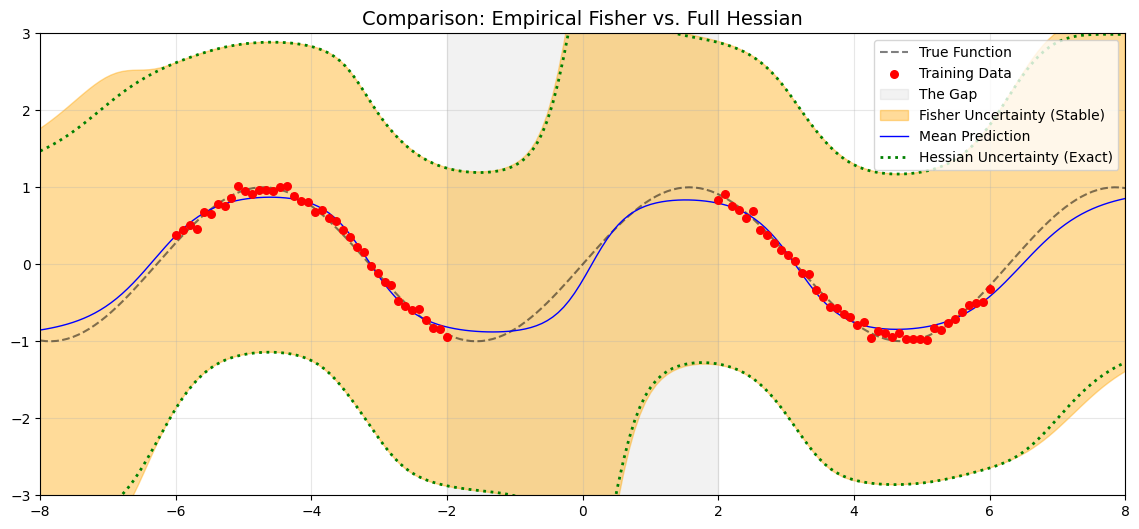

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(X_test.numpy(), y_true.numpy(), 'k--', alpha=0.5, label='True Function')
plt.scatter(X_train.numpy(), y_train.numpy(), c='red', s=30, zorder=5, label='Training Data')
plt.axvspan(-2, 2, color='gray', alpha=0.1, label='The Gap')
vars_F = np.maximum(F, 0)
plt.fill_between(X_test.flatten(), 
                 y_pred_map - 2*np.sqrt(vars_F), 
                 y_pred_map + 2*np.sqrt(vars_F), 
                 color='orange', alpha=0.4, label='Fisher Uncertainty (Stable)')

lower_H = preds_H - 2*np.sqrt(vars_H)
upper_H = preds_H + 2*np.sqrt(vars_H)

plt.plot(X_test.flatten(), preds_H, 'b-', linewidth=1, label='Mean Prediction')
plt.plot(X_test.flatten(), lower_H, color='green', linestyle=':', linewidth=2)
plt.plot(X_test.flatten(), upper_H, color='green', linestyle=':', linewidth=2, label='Hessian Uncertainty (Exact)')

plt.title("Comparison: Empirical Fisher vs. Full Hessian", fontsize=14)
plt.legend(loc='upper right')
plt.ylim(-3.0, 3.0) 
plt.xlim(-8, 8)
plt.grid(True, alpha=0.3)
plt.show()

# Application to Real Data (Boston Housing)

We will now apply the Laplace Approximation (using the Hessian) to the Boston Housing dataset, using only 2 features for visualization purposes.

1. **Data**: Load Boston Housing, select 'RM' and 'LSTAT', and normalize.
2. **Model**: Train a Neural Network to get the MAP estimate.
3. **Uncertainty**: Compute the Hessian at $\omega_{MAP}$ and visualize the predictive variance surface.

In [ ]:
# --- Boston Housing Data Preparation ---
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load Boston Housing dataset
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Select features 'RM' (index 5) and 'LSTAT' (index 12)
X_boston = data[:, [5, 12]]
y_boston = target.reshape(-1, 1)

# Normalize features
scaler_X = StandardScaler()
X_boston = scaler_X.fit_transform(X_boston)
scaler_y = StandardScaler()
y_boston = scaler_y.fit_transform(y_boston)

# Grid for visualization (2D)
x_range = np.linspace(X_boston[:, 0].min(), X_boston[:, 0].max(), 50)
y_range = np.linspace(X_boston[:, 1].min(), X_boston[:, 1].max(), 50)
X1_grid, X2_grid = np.meshgrid(x_range, y_range)
X_boston_grid = np.hstack([X1_grid.ravel().reshape(-1, 1), X2_grid.ravel().reshape(-1, 1)])

# Convert to Tensor if using PyTorch in this notebook (Q2 uses PyTorch)
X_boston_th = torch.tensor(X_boston, dtype=torch.float32)
y_boston_th = torch.tensor(y_boston, dtype=torch.float32)
X_boston_grid_th = torch.tensor(X_boston_grid, dtype=torch.float32)

In [ ]:
# --- Train MAP and Visualize Uncertainty ---
# TODO: 
# 1. Define and train a Neural Network on X_boston_th, y_boston_th (MAP estimate)
# 2. Compute the Hessian H of the loss w.r.t weights at w_MAP
# 3. Compute the predictive variance for the grid points X_boston_grid_th
#    sigma^2(x) = sigma_y^2 + g(x)^T H^-1 g(x)
# 4. Visualize the mean prediction and variance surface (e.g. using plt.contourf)
pass